# EDA - GiveMeSomeCredit Test Dataset
## Análisis Exploratorio de Datos - cs-test.csv

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 2. Carga de Datos

In [2]:
import os
p = 'data/GiveMeSomeCredit/cs-test.csv'
if os.path.exists(p):
    df = pd.read_csv(p, index_col=0)
    print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"\nPrimeras filas:")
    df.head()
else:
    print(f'File not found: {p}. Skipping load.')
    df = pd.DataFrame()

Dataset cargado: 101,503 filas × 11 columnas

Primeras filas:


## 3. Información General

In [3]:
if df.empty or len(df.columns) == 0:
    print("No hay datos cargados o no hay columnas para describir. Se omite la información general.")
else:
    print("Info del dataset:")
    df.info()
    print("\n" + "="*80 + "\n")
    print("Estadísticas descriptivas:")
    df.describe()

Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 101503 entries, 1 to 101503
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      0 non-null       float64
 1   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 2   age                                   101503 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 4   DebtRatio                             101503 non-null  float64
 5   MonthlyIncome                         81400 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 7   NumberOfTimes90DaysLate               101503 non-null  int64  
 8   NumberRealEstateLoansOrLines          101503 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 10  NumberOfDependents                    98877 non-null   float6

## 4. Análisis de Valores Faltantes

Valores faltantes:
                    Faltantes  Porcentaje
SeriousDlqin2yrs       101503  100.000000
MonthlyIncome           20103   19.805326
NumberOfDependents       2626    2.587116


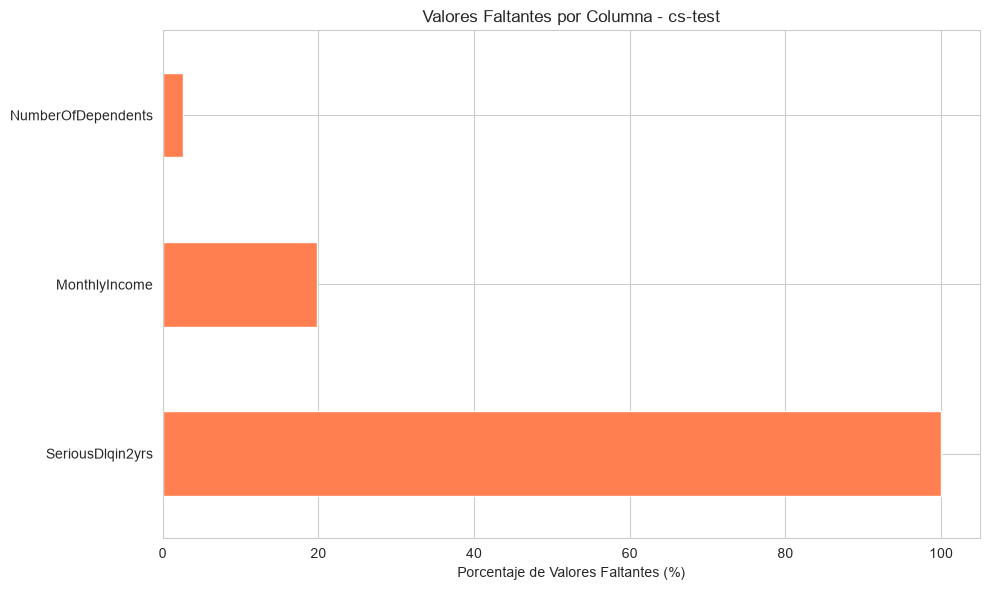

In [4]:
# Valores faltantes
if df.empty:
    print("No hay datos cargados. Se omite el análisis de valores faltantes.")
else:
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_percent})
    missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

    print("Valores faltantes:")
    print(missing_df)

# Gráfico de valores faltantes
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df['Porcentaje'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Porcentaje de Valores Faltantes (%)')
    ax.set_title('Valores Faltantes por Columna - cs-test')
    plt.tight_layout()
    plt.show()
else:
    print("No hay valores faltantes en el dataset")

## 5. Distribución de la Variable Objetivo

In [5]:
# Variable objetivo (generalmente la primera columna)
target_col = df.columns[0]

# El dataset de prueba no siempre incluye etiquetas objetivo completas.
# Usamos dropna() para evitar errores con NaN en la columna de etiqueta.
target_counts = df[target_col].dropna().value_counts()

if target_counts.empty:
    print(f"La columna objetivo '{target_col}' sólo contiene valores faltantes o está vacía. Se omite el análisis de distribución.")
else:
    colors = ['green', 'red'][:len(target_counts)]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Conteo
    axes[0].bar([str(x) for x in target_counts.index], target_counts.values, color=colors)
    axes[0].set_title(f'Distribución de {target_col}')
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel('Cantidad')

    # Porcentaje
    labels = [str(int(val)) if isinstance(val, (int, np.integer)) or (isinstance(val, float) and val.is_integer()) else str(val) for val in target_counts.index]
    axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%', colors=colors)
    axes[1].set_title(f'Proporción de {target_col}')

    plt.tight_layout()
    plt.show()

    print(f"Distribución de {target_col}:")
    print(target_counts)
    print(f"\nPorcentajes:")
    print(target_counts / len(df) * 100)

La columna objetivo 'SeriousDlqin2yrs' sólo contiene valores faltantes o está vacía. Se omite el análisis de distribución.


## 6. Análisis por Tipo de Variable

In [6]:
# Separar variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"\nColumnas categóricas ({len(categorical_cols)}): {categorical_cols}")

Columnas numéricas (11): ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Columnas categóricas (0): []


## 7. Distribuciones de Variables Numéricas

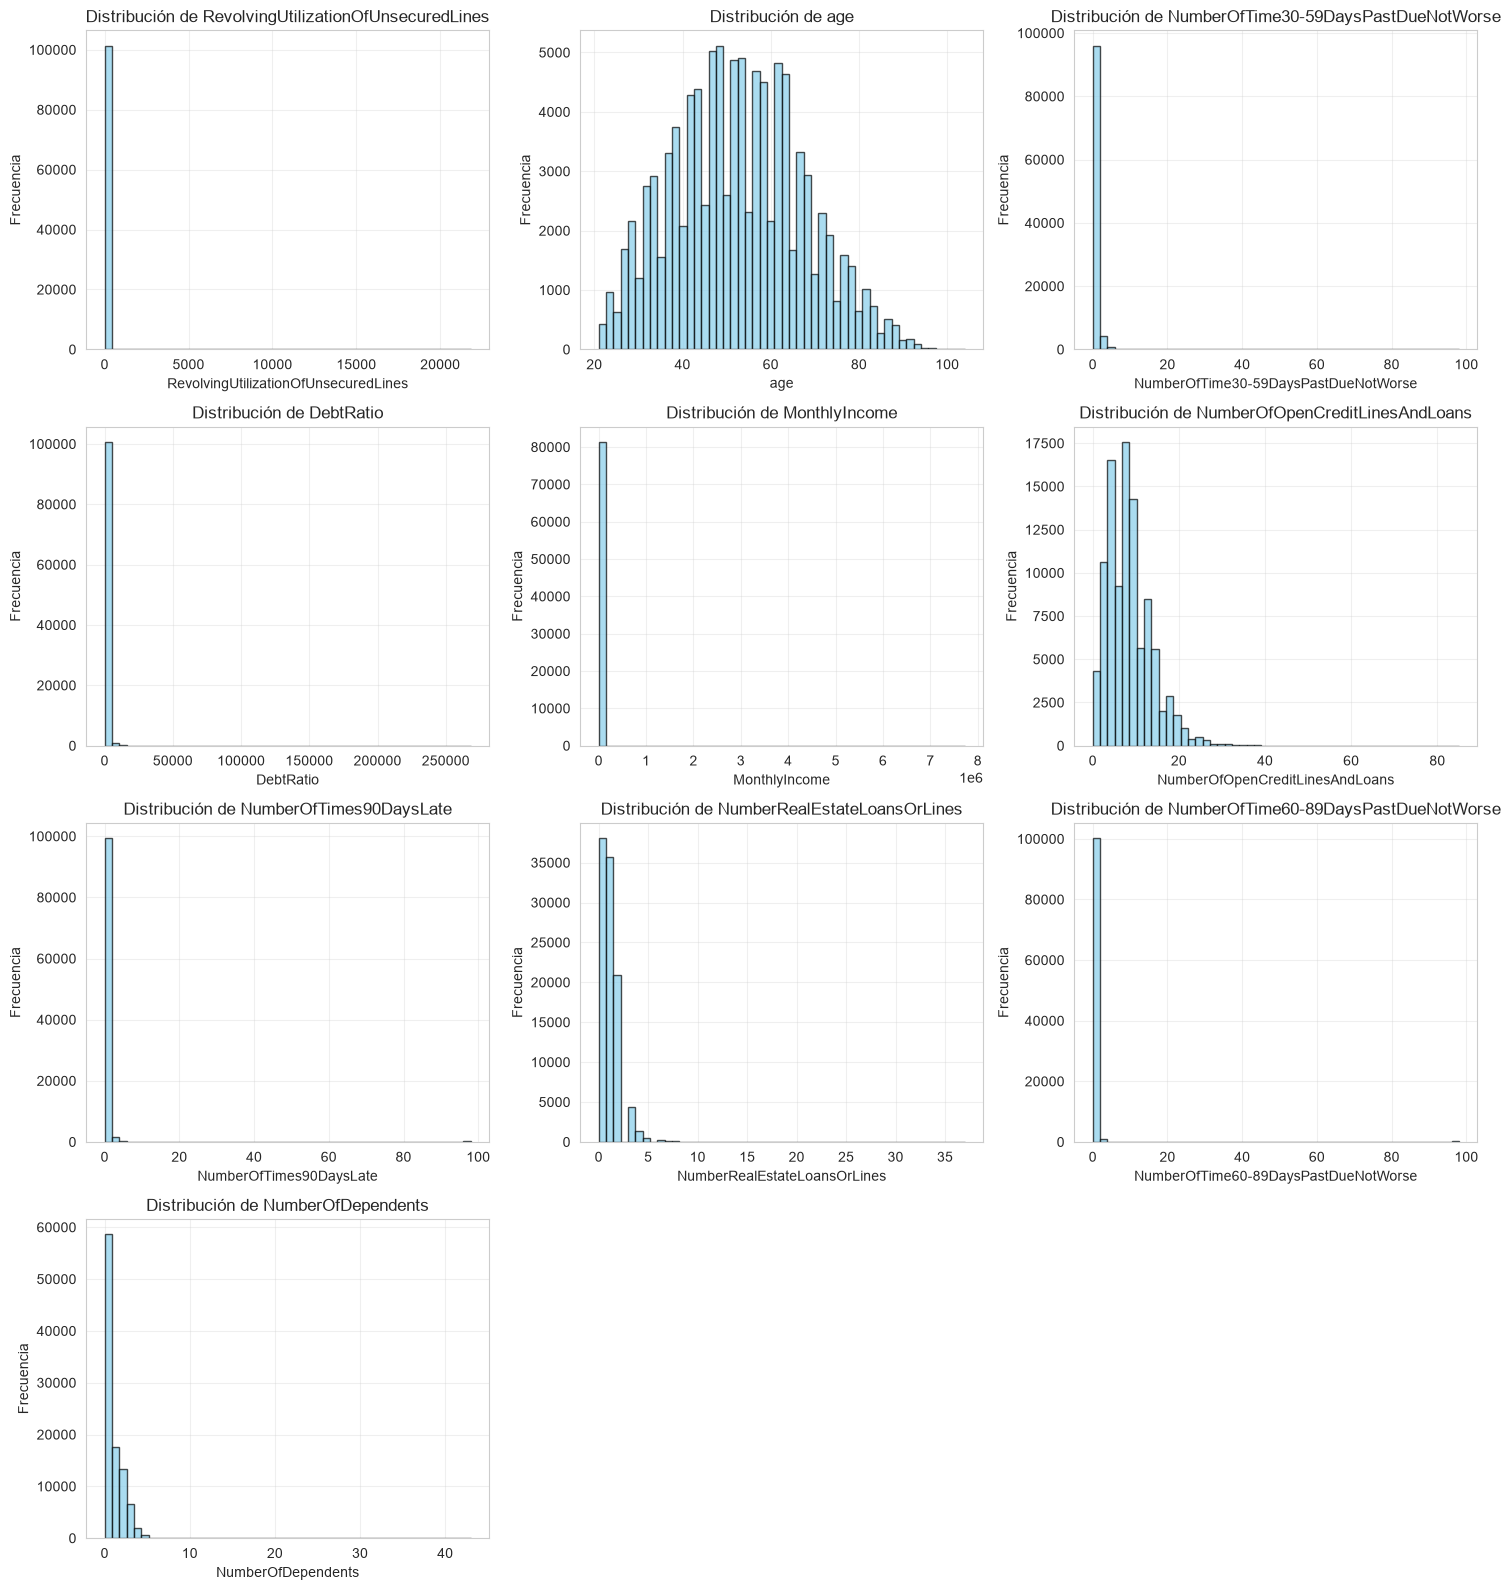

In [7]:
# Histogramas de variables numéricas
numeric_cols_clean = [col for col in numeric_cols if col != target_col]

if numeric_cols_clean:
    n_cols = min(3, len(numeric_cols_clean))
    n_rows = (len(numeric_cols_clean) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols_clean[:len(axes)]):
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
        axes[idx].set_title(f'Distribución de {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(alpha=0.3)
    
    # Ocultar ejes no usados
    for idx in range(len(numeric_cols_clean), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 8. Estadísticas de Correlación

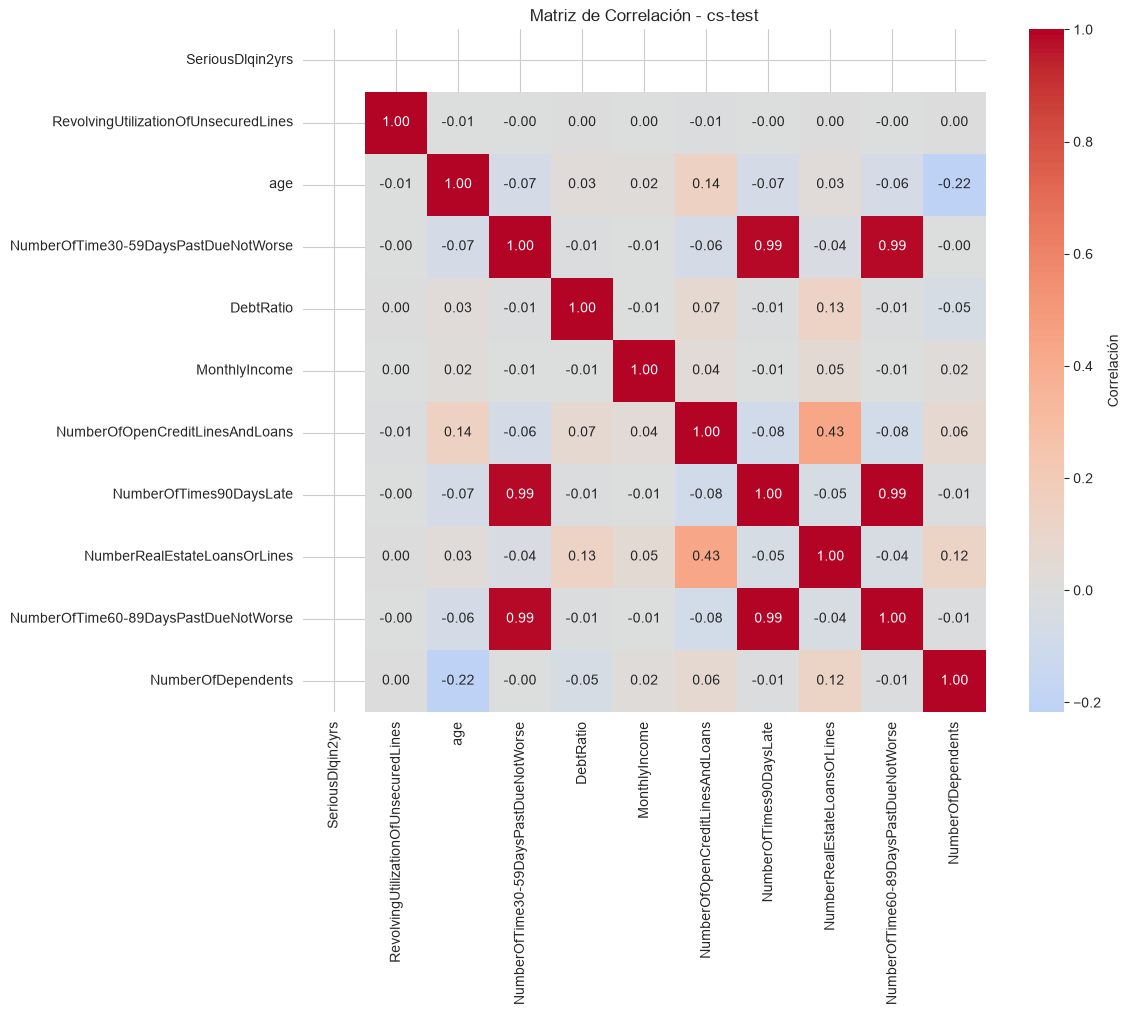


Correlaciones más altas con la variable objetivo:
SeriousDlqin2yrs                       NaN
RevolvingUtilizationOfUnsecuredLines   NaN
age                                    NaN
NumberOfTime30-59DaysPastDueNotWorse   NaN
DebtRatio                              NaN
MonthlyIncome                          NaN
NumberOfOpenCreditLinesAndLoans        NaN
NumberOfTimes90DaysLate                NaN
NumberRealEstateLoansOrLines           NaN
NumberOfTime60-89DaysPastDueNotWorse   NaN
Name: SeriousDlqin2yrs, dtype: float64


In [8]:
# Matriz de correlación
if len(numeric_cols) == 0:
    print("No hay columnas numéricas disponibles para calcular la matriz de correlación.")
else:
    correlation_matrix = df[numeric_cols].corr()

    if correlation_matrix.empty:
        print("La matriz de correlación está vacía. No hay datos numéricos suficientes para calcular correlaciones.")
    else:
        # Heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    cbar_kws={'label': 'Correlación'}, square=True)
        plt.title('Matriz de Correlación - cs-test')
        plt.tight_layout()
        plt.show()

        print("\nCorrelaciones más altas con la variable objetivo:")
        if target_col in correlation_matrix.columns:
            target_corr = correlation_matrix[target_col].sort_values(ascending=False)
            print(target_corr.head(10))
        else:
            print(f"La columna objetivo '{target_col}' no es numérica o no forma parte de la matriz de correlación.")

## 9. Detección de Outliers

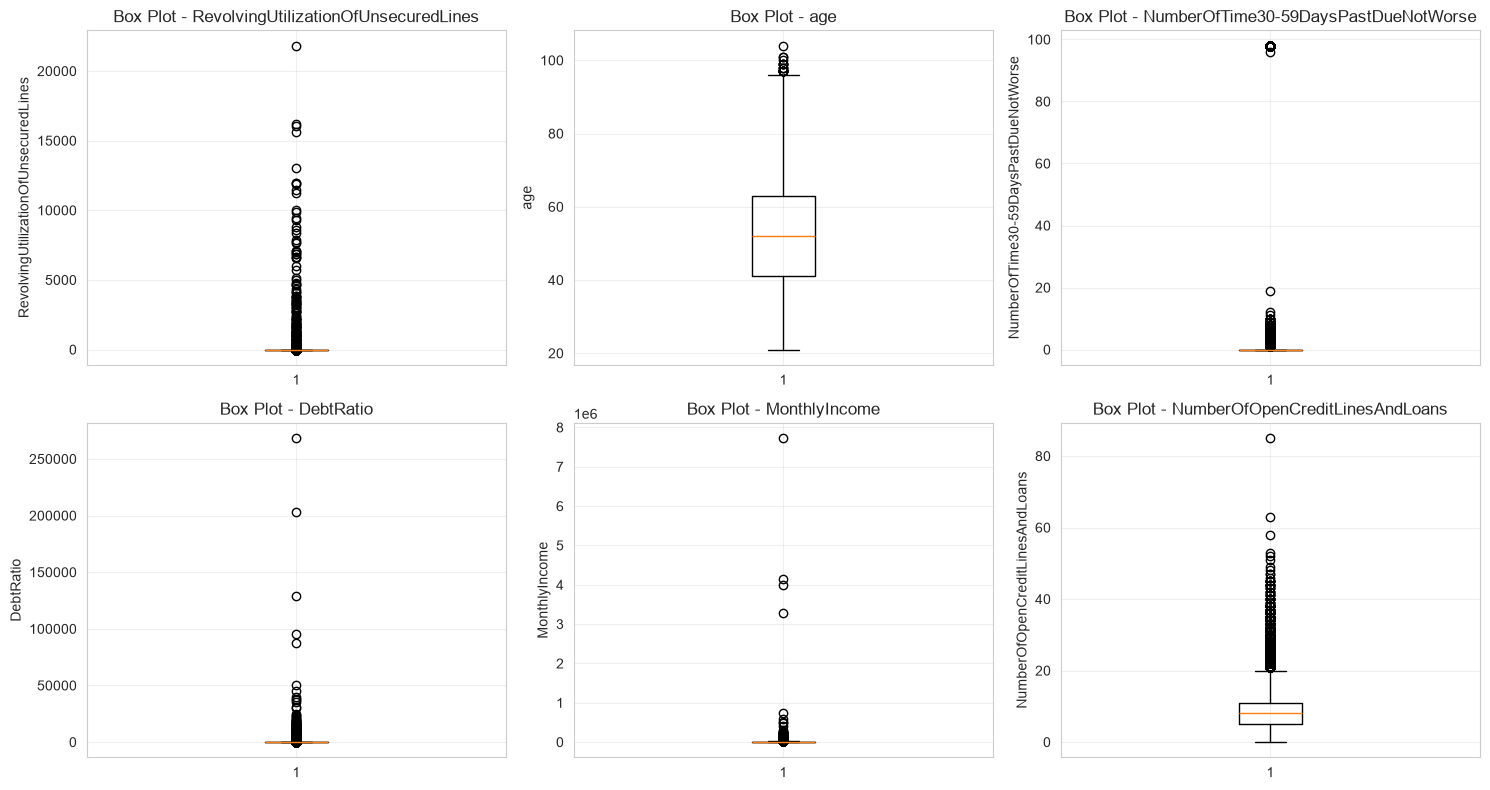

In [9]:
# Box plots para detectar outliers
numeric_cols_clean = [col for col in numeric_cols if col != target_col][:6]  # Primeras 6

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols_clean):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'Box Plot - {col}')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Resumen de Hallazgos

In [10]:
print("=" * 80)
print("RESUMEN - DATASET cs-test.csv")
print("=" * 80)
print(f"\n Tamaño del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n Variables numéricas: {len(numeric_cols)}")
print(f" Variables categóricas: {len(categorical_cols)}")
print(f"\n Filas con valores faltantes: {df.isnull().any(axis=1).sum():,}")
print(f"\n Filas completas: {len(df) - df.isnull().any(axis=1).sum():,}")
print("\n" + "=" * 80)

RESUMEN - DATASET cs-test.csv

 Tamaño del dataset: 101,503 filas × 11 columnas

 Variables numéricas: 11
 Variables categóricas: 0

 Filas con valores faltantes: 101,503

 Filas completas: 0

